# 02 — Probe analysis

Difference-of-means, layer-wise logistic regression, and PCA — run end to end for **both** probe targets:

- **`answerable`** — gold ground truth (does the model *represent* answerability)
- **`abstained_correctly`** — behaviour (does it *act* on it)

**Inputs:** `acts_layer_{i}.pt`, `responses.json`, `labels.csv` (results dir).
**Outputs (per target):** `probe_accuracy_{label}.csv`, `dom_vectors_{label}.pt`, and figures `probe_accuracy_by_layer_{label}.png`, `dom_cosine_{label}.png`, `pca_variance_{label}.png`, `pca_peak_layer_{label}.png`. Plus the comparison figure `probe_accuracy_comparison.png`.

Step 1 (the judge) needs a GPU; Steps 2–5 run fine on local CPU.

In [1]:
# --- Colab setup (skip these two lines when running locally) ---
from google.colab import drive; drive.mount('/content/drive')
%cd "/content/drive/Othercomputers/My MacBook Air/abstention-geometry"
import sys
from pathlib import Path
sys.path.append(str(Path.cwd().parent))

Mounted at /content/drive
/content/drive/Othercomputers/My MacBook Air/abstention-geometry


In [2]:
import json

import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt

from src.data import load_selfaware
from src.judge import load_judge, judge_responses, save_labels
from src.paths import results_dir
from src.probes import (
    load_activations,
    difference_of_means,
    train_logistic_probes,
    pca_analysis,
    plot_probe_accuracy,
)

In [3]:
import src

# Resolve paths from the src package location, not the working directory —
# robust whether or not the Colab %cd above succeeded.
REPO_ROOT = Path(src.__file__).resolve().parent.parent
DATA_PATH = str(REPO_ROOT / 'data' / 'selfaware' / 'SelfAware.json')
RESULTS_DIR = results_dir()  # Drive on Colab, repo results/ locally; override with $RESULTS_DIR
print('DATA_PATH   =', DATA_PATH)
print('RESULTS_DIR =', RESULTS_DIR)

DATA_PATH   = /content/drive/Othercomputers/My MacBook Air/abstention-geometry/data/selfaware/SelfAware.json
RESULTS_DIR = /content/drive/Othercomputers/My MacBook Air/abstention-geometry/results/


## Step 1 — run the judge on cached responses

Adds `judge_label` to the dataset so we have both `answerable` (gold) and `judge_label` (model-behavior) labels available.

In [4]:
# df = load_selfaware(DATA_PATH)
# responses_payload = json.load(open(RESULTS_DIR + 'responses.json'))
# judge_model, judge_tok = load_judge()
# labels = judge_responses(judge_model, judge_tok, df['question'].tolist(), responses_payload['response'])
# save_labels(df, responses_payload['response'], labels, path=RESULTS_DIR + 'labels.csv')
# print(pd.Series(labels).value_counts())
# print('saved', RESULTS_DIR + 'labels.csv')

In [5]:
# # Spot-check the judge: 15 random questions, Llama's answer, and the judge's
# # label — to cross-check against your own read. Re-run the cell for a fresh 15.
# ldf = pd.read_csv(RESULTS_DIR + 'labels.csv')
# print('judge label distribution:')
# print(ldf['judge_label'].value_counts(), '\n')

# for n, (_, r) in enumerate(ldf.sample(15).iterrows(), 1):
#     print(f"=== {n}.  judge: {r['judge_label'].upper()}   |   gold answerable: {r['answerable']} ===")
#     print('Q:', r['question'])
#     print('A:', ' '.join(str(r['model_response']).split())[:400])
#     print()

## Step 2 — load activations and build both probe targets

Two binary targets, each analysed in full below:

- **`answerable`** — gold ground truth: is the question answerable at all. Tests whether the model *represents* answerability.
- **`abstained_correctly`** — behaviour: the model abstained on an unanswerable question (`abstained` judge label AND not `answerable`). Tests whether the model *acts* on it.

The three-way `outcome` (`correct` / `wrong` / `abstained_correctly`) is computed as an intermediate.

In [6]:
acts_by_layer = load_activations(RESULTS_DIR)
layers = sorted(acts_by_layer.keys())
print(f'{len(layers)} layers cached | per-layer activation shape {acts_by_layer[layers[0]].shape}')

ldf = pd.read_csv(RESULTS_DIR + 'labels.csv')


def outcome(row):
    abstained = row['judge_label'] == 'abstained'
    answered = row['judge_label'] == 'answered'
    if abstained and not row['answerable']:
        return 'abstained_correctly'
    if answered and row['answerable']:
        return 'correct'
    return 'wrong'


ldf['outcome'] = ldf.apply(outcome, axis=1)
print('\noutcome distribution:')
print(ldf['outcome'].value_counts())

# Two binary probe targets, each analysed in full in Step 4.
targets = {
    'answerable': ldf['answerable'].astype(int).to_numpy(),
    'abstained_correctly': (ldf['outcome'] == 'abstained_correctly').astype(int).to_numpy(),
}

n = acts_by_layer[layers[0]].shape[0]
print()
for name, y in targets.items():
    assert len(y) == n, f'{name}: labels and activations are misaligned'
    print(f'{name:22s} positive rate {y.mean():.3f}  |  N = {len(y)}')

32 layers cached | per-layer activation shape (3369, 4096)

outcome distribution:
outcome
correct                1696
wrong                  1421
abstained_correctly     252
Name: count, dtype: int64

answerable             positive rate 0.694  |  N = 3369
abstained_correctly    positive rate 0.075  |  N = 3369


## Step 3 — per-label analysis pipeline

`analyse_label` runs all three probes for one target and writes its tables and figures, each suffixed with the label name:

- **difference-of-means** direction per layer → `dom_vectors_{label}.pt` + cross-layer cosine heatmap
- **logistic probe** sweep, 5-fold CV → `probe_accuracy_{label}.csv` + accuracy-by-layer figure
- **PCA** — top-2 variance per layer, and a PC1/PC2 scatter at the peak layer

Defined once here, run for both targets in Step 4.

In [7]:
FIG_DIR = REPO_ROOT / 'figures'
FIG_DIR.mkdir(parents=True, exist_ok=True)


def analyse_label(label, y, acts_by_layer, layers):
    """Run all three probes for one binary target; save its tables + figures.

    Writes (each suffixed with `label`): dom_vectors_{label}.pt,
    probe_accuracy_{label}.csv, and the dom_cosine / probe_accuracy_by_layer /
    pca_variance / pca_peak_layer figures. Returns the probe-accuracy DataFrame.
    """
    print(f'\n=== {label}  (positive rate {y.mean():.3f}) ===')

    # --- difference-of-means direction per layer + cross-layer cosine ---
    dom = {l: difference_of_means(acts_by_layer[l], y) for l in layers}
    torch.save({l: torch.from_numpy(dom[l]) for l in layers},
               RESULTS_DIR + f'dom_vectors_{label}.pt')
    D = np.stack([dom[l] for l in layers])
    cos = D @ D.T
    fig, ax = plt.subplots(figsize=(5.5, 4.5))
    im = ax.imshow(cos, cmap='viridis', vmin=-1, vmax=1, origin='lower',
                   extent=[layers[0], layers[-1], layers[0], layers[-1]])
    ax.set_xlabel('layer'); ax.set_ylabel('layer')
    ax.set_title(f'Difference-of-means cosine similarity\n({label})')
    fig.colorbar(im, label='cosine similarity')
    fig.tight_layout()
    fig.savefig(FIG_DIR / f'dom_cosine_{label}.png', dpi=150)
    plt.show()

    # --- logistic probe sweep (5-fold CV, balanced accuracy) ---
    probe_df = train_logistic_probes(acts_by_layer, y)
    probe_df.to_csv(RESULTS_DIR + f'probe_accuracy_{label}.csv', index=False)
    plot_probe_accuracy(probe_df,
                        save_path=str(FIG_DIR / f'probe_accuracy_by_layer_{label}.png'),
                        title=f'Probe accuracy by layer ({label})')
    peak_layer = int(probe_df.loc[probe_df['mean_balanced_accuracy'].idxmax(), 'layer'])
    print(f'peak layer {peak_layer}  |  '
          f'balanced accuracy {probe_df["mean_balanced_accuracy"].max():.3f}')

    # --- PCA: top-2 variance by layer, then a scatter at the peak layer ---
    var_top2 = [pca_analysis(acts_by_layer[l], y)['explained_variance_ratio'][:2].sum()
                for l in layers]
    fig, ax = plt.subplots(figsize=(7, 4))
    ax.plot(layers, var_top2, marker='o')
    ax.set_xlabel('layer'); ax.set_ylabel('variance explained by PC1 + PC2')
    ax.set_title(f'Top-2 PC variance by layer ({label})')
    fig.tight_layout()
    fig.savefig(FIG_DIR / f'pca_variance_{label}.png', dpi=150)
    plt.show()

    pca = pca_analysis(acts_by_layer[peak_layer], y)
    proj = pca['projected']
    fig, ax = plt.subplots(figsize=(6, 5))
    for cls, color, name in [(0, 'tab:gray', 'negative'), (1, 'tab:red', label)]:
        m = pca['labels'] == cls
        ax.scatter(proj[m, 0], proj[m, 1], s=8, alpha=0.35, c=color, label=name)
    ax.set_xlabel('PC1'); ax.set_ylabel('PC2')
    ax.set_title(f'PCA at peak layer {peak_layer} ({label})\n'
                 f'PC1+PC2 = {pca["explained_variance_ratio"][:2].sum():.0%} variance')
    ax.legend()
    fig.tight_layout()
    fig.savefig(FIG_DIR / f'pca_peak_layer_{label}.png', dpi=150)
    plt.show()

    return probe_df

## Step 4 — run the full analysis for both targets

Produces every table and figure for `answerable` and `abstained_correctly`. Two logistic sweeps over 32 layers with 5-fold CV — a few minutes on CPU.


=== answerable  (positive rate 0.694) ===


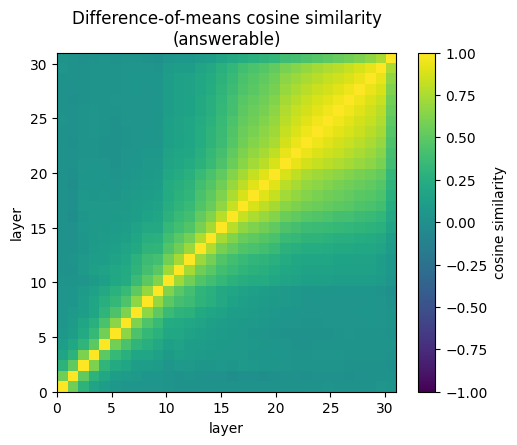

peak layer 15  |  balanced accuracy 0.974


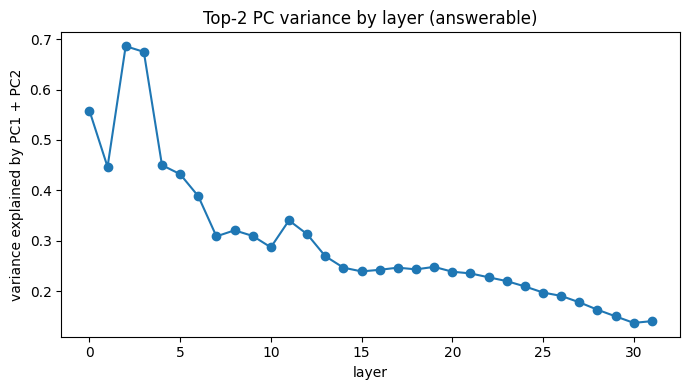

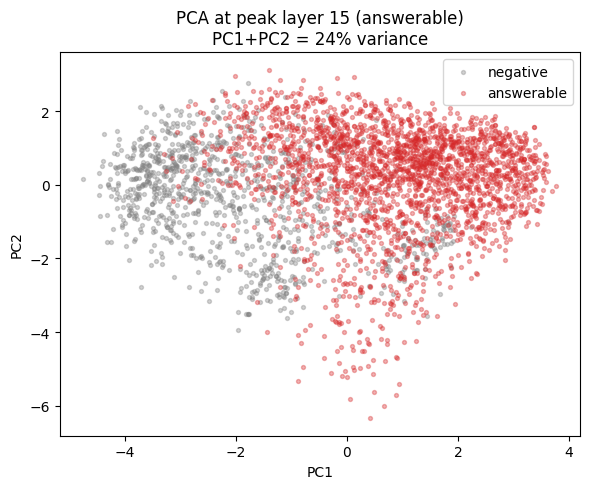


=== abstained_correctly  (positive rate 0.075) ===


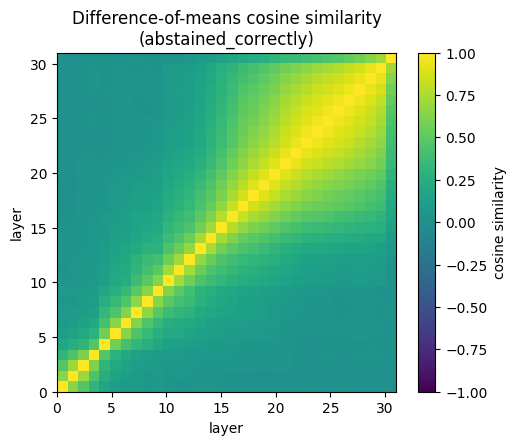

peak layer 31  |  balanced accuracy 0.741


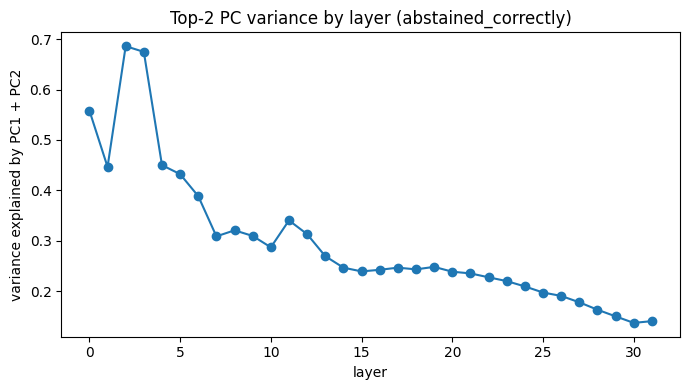

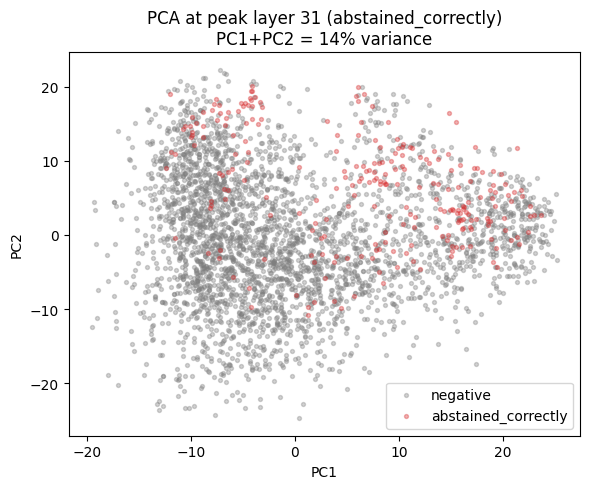

In [8]:
probe_results = {
    label: analyse_label(label, y, acts_by_layer, layers)
    for label, y in targets.items()
}

## Step 5 — comparison figure

Both probe-accuracy curves on one axes. The gap between the near-ceiling `answerable` curve and the lower `abstained_correctly` curve is the headline result: the model *represents* unanswerability far better than it *acts* on it.

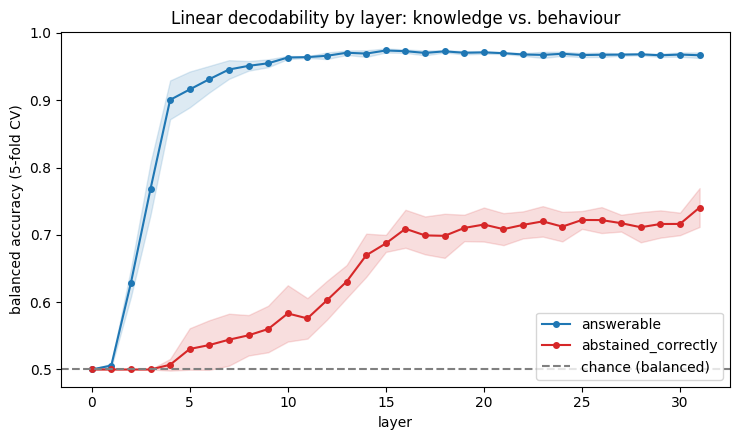

In [9]:
colors = {'answerable': 'tab:blue', 'abstained_correctly': 'tab:red'}

fig, ax = plt.subplots(figsize=(7.5, 4.5))
for label, pdf in probe_results.items():
    c = colors.get(label)
    ax.plot(pdf['layer'], pdf['mean_balanced_accuracy'], marker='o', ms=4,
            color=c, label=label)
    ax.fill_between(pdf['layer'],
                    pdf['mean_balanced_accuracy'] - pdf['std_balanced_accuracy'],
                    pdf['mean_balanced_accuracy'] + pdf['std_balanced_accuracy'],
                    color=c, alpha=0.15)
ax.axhline(0.5, ls='--', color='gray', label='chance (balanced)')
ax.set_xlabel('layer')
ax.set_ylabel('balanced accuracy (5-fold CV)')
ax.set_title('Linear decodability by layer: knowledge vs. behaviour')
ax.legend()
fig.tight_layout()
fig.savefig(FIG_DIR / 'probe_accuracy_comparison.png', dpi=150)
plt.show()